In [1]:
import numpy as np
from Corrfunc.theory import wp
from Corrfunc.theory.DDrppi import DDrppi
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolor
import statistics
import seaborn as sns

In [2]:
def error_data(rpavg_, wp_):
    wp_mean = []
    rpavg_mean = []
    stdev_ = []
    for i in range(len(wp_[0])):
        all_wp = []
        all_rpavg = []
        for arr in range(len(wp_)):
            all_wp.append(wp_[arr][i])
            all_rpavg.append(rpavg_[arr][i])
        wp_mean.append(statistics.mean(all_wp))
        rpavg_mean.append(statistics.mean(all_rpavg))
        stdev_.append(statistics.stdev(all_wp))
    return rpavg_mean, wp_mean, stdev_

In [ ]:
# Going through 
file = "wp_ph000.npz"
data = np.load(file)
all_wp = data['wp_']
all_rp = data['rp_avg']
wp_means = []
__r, wp_m, __s = error_data(all_rp, all_wp)
wp_means.append(wp_m)
for i in range (1, 25):
    file = f"wp_ph{i:03d}.npz"
    data = np.load(file)
    all_wp = np.concatenate((all_wp, data['wp_']))
    all_rp = np.concatenate((all_rp, data['rp_avg']))
    rp_temp, wp_temp, stdev_temp = error_data(data['rp_avg'], data['wp_'])
    wp_means.append(wp_temp)
print(len(wp_means))
print(type(all_wp))

25
<class 'numpy.ndarray'>


<Axes: >

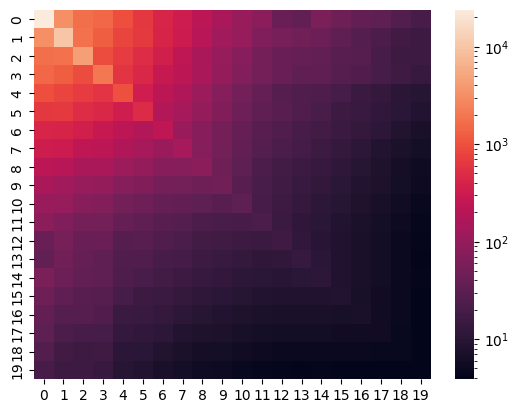

In [4]:
cov_matrix = np.cov(all_wp, rowvar = False)
sns.heatmap(cov_matrix, norm = mplcolor.LogNorm())

<Axes: >

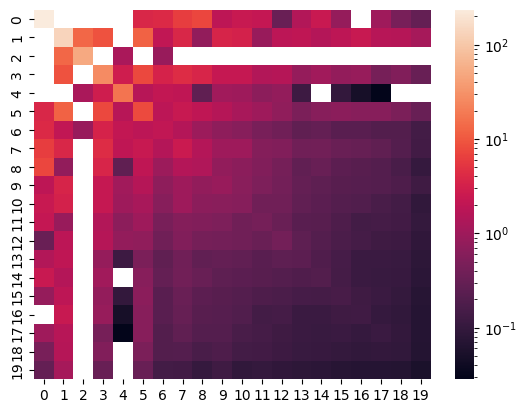

In [5]:
cov_matrix_25 = np.cov(wp_means, rowvar = False)
sns.heatmap(cov_matrix_25, norm = mplcolor.LogNorm())